# 1. Project Introduction

This notebook builds a vanilla Data Science workflow for predictive maintenance using the UCI AI4I 2020 Predictive Maintenance Dataset.

Predictive maintenance means using machine condition data to estimate whether equipment is likely to fail, so maintenance teams can inspect risky machines before an unexpected breakdown occurs.

# 2. Business Problem

The business question is: given current machine operating conditions, can we estimate failure risk and provide a simple maintenance-oriented interpretation?

In this project, a false negative is especially important because it means the model predicts normal operation when the machine actually fails.

# 3. Dataset Description

The dataset contains product type, operating temperatures, rotational speed, torque, tool wear, failure-mode indicators, and the target column `Machine failure`.

For the intended real-world prediction scenario, the model should use information that would be available before failure, such as machine type and operating measurements.

# 4. Import Libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_processing import (
    BASE_NUMERIC_FEATURES,
    DEFAULT_DATA_PATH,
    FAILURE_MODE_COLUMNS,
    IDENTIFIER_COLUMNS,
    TARGET_COLUMN,
    add_engineered_features,
    clean_data,
    get_model_feature_columns,
    inspect_dataset,
    load_dataset,
    split_train_validation_test,
)
from src.model_training import (
    build_models,
    build_preprocessor,
    confusion_matrix_dataframe,
    evaluate_model,
    feature_importance_dataframe,
    fit_and_evaluate_models,
    threshold_analysis,
)
from src.prediction import predict_machine_failure

sns.set_theme(style="whitegrid")

# 5. Load Dataset

The project expects the CSV at `data/raw/ai4i2020.csv`. If your file has a different name, update `DEFAULT_DATA_PATH` in `src/data_processing.py`.

In [2]:
df = load_dataset(DEFAULT_DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# 6. Initial Data Inspection

In [3]:
inspection = inspect_dataset(df)

print(f"Rows: {inspection['shape'][0]}")
print(f"Columns: {inspection['shape'][1]}")
print(f"Duplicate rows: {inspection['duplicate_count']}")

display(df.head())
display(df.describe(include="all"))
display(pd.DataFrame({"dtype": inspection["data_types"].astype(str), "missing_values": inspection["missing_values"]}))
display(inspection["target_distribution"])
print("Categorical columns:", inspection["categorical_columns"])
print("Numerical columns:", inspection["numerical_columns"])

Rows: 10000
Columns: 14
Duplicate rows: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


,dtype,missing_values
UDI,int64,0
Product ID,str,0
Type,str,0
Air temperature [K],float64,0
Process temperature [K],float64,0
Rotational speed [rpm],int64,0
Torque [Nm],float64,0
Tool wear [min],int64,0
Machine failure,int64,0
TWF,int64,0


Machine failure
0    9661
1     339
Name: count, dtype: int64

Categorical columns: ['Product ID', 'Type']
Numerical columns: ['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

# 7. Data Cleaning

Cleaning is kept conservative. We check missing values, duplicates, data types, and obviously suspicious values without removing rows just because they look extreme.

In [5]:
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary)

if missing_summary.sum() == 0:
    print("No missing values found.")

print(f"Duplicate rows before cleaning: {df.duplicated().sum()}")
clean_df = clean_data(df)
print(f"Duplicate rows after cleaning: {clean_df.duplicated().sum()}")
display(clean_df.dtypes)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

No missing values found.
Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


UDI                           int64
Product ID                      str
Type                       category
Air temperature [K]         float64
Process temperature [K]     float64
Rotational speed [rpm]        int64
Torque [Nm]                 float64
Tool wear [min]               int64
Machine failure               int64
TWF                           int64
HDF                           int64
PWF                           int64
OSF                           int64
RNF                           int64
dtype: object

In [6]:
validity_checks = pd.DataFrame(
    {
        "minimum": clean_df[BASE_NUMERIC_FEATURES].min(),
        "maximum": clean_df[BASE_NUMERIC_FEATURES].max(),
    }
)
display(validity_checks)
print("Review these ranges for impossible or suspicious values before modelling.")

,minimum,maximum
Air temperature [K],295.3,304.5
Process temperature [K],305.7,313.8
Rotational speed [rpm],1168.0,2886.0
Torque [Nm],3.8,76.6
Tool wear [min],0.0,253.0


Review these ranges for impossible or suspicious values before modelling.


# 8. Target Distribution

This section checks whether failures are rare. If failures are rare, accuracy can look high even when the model misses many failures.

,count,rate
Machine failure,,
0,9661,0.9661
1,339,0.0339


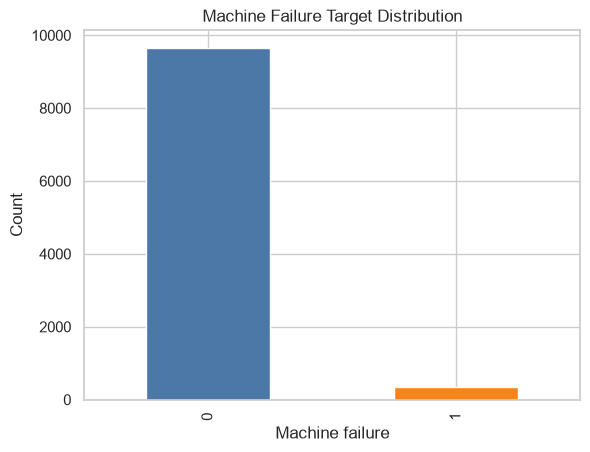

In [7]:
target_counts = clean_df[TARGET_COLUMN].value_counts().sort_index()
target_rates = clean_df[TARGET_COLUMN].value_counts(normalize=True).sort_index()
display(pd.DataFrame({"count": target_counts, "rate": target_rates}))

ax = target_counts.plot(kind="bar", color=["#4C78A8", "#F58518"])
ax.set_title("Machine Failure Target Distribution")
ax.set_xlabel("Machine failure")
ax.set_ylabel("Count")
plt.show()

# 9. Exploratory Data Analysis

The EDA focuses on a small set of practical questions: whether failures are rare, how operating variables differ by failure status, whether outliers are present, whether variables are correlated, and whether product type appears associated with failure rate.

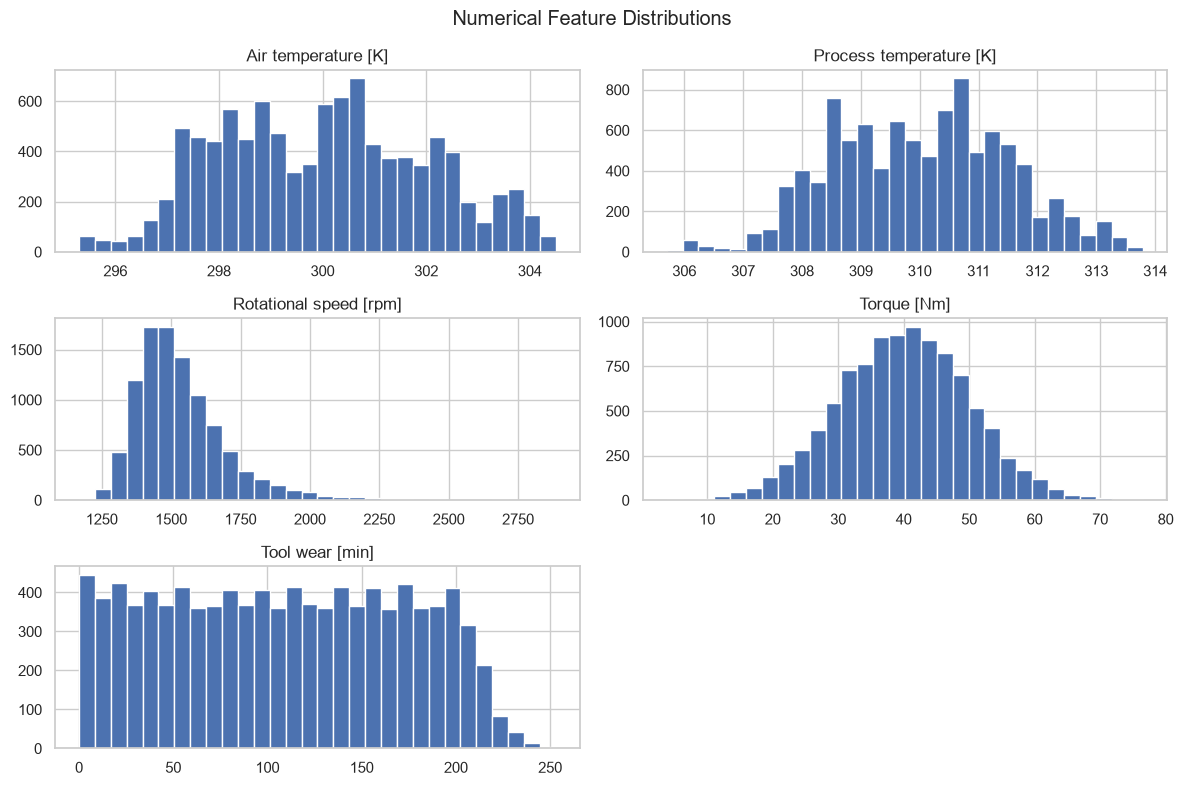

In [8]:
clean_df[BASE_NUMERIC_FEATURES].hist(figsize=(12, 8), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

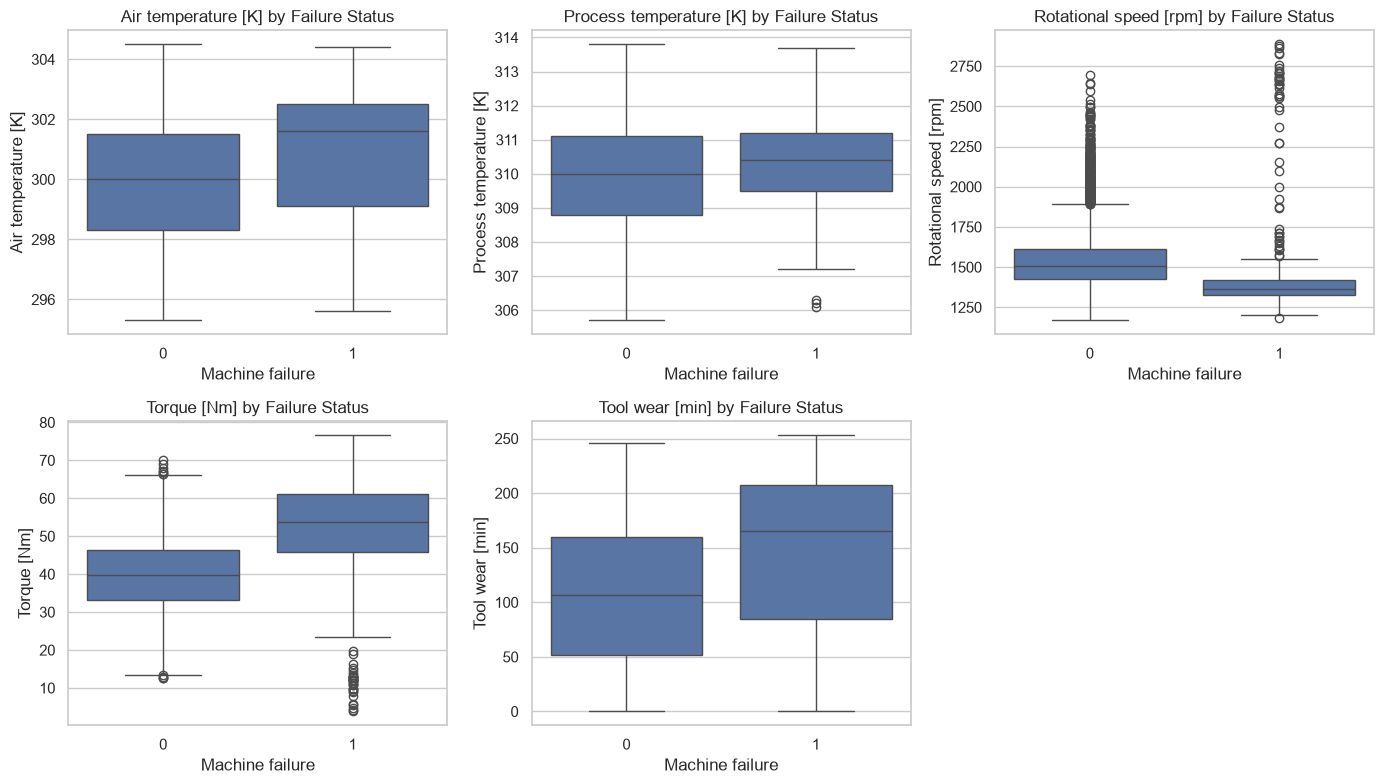

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for index, column in enumerate(BASE_NUMERIC_FEATURES):
    sns.boxplot(data=clean_df, x=TARGET_COLUMN, y=column, ax=axes[index])
    axes[index].set_title(f"{column} by Failure Status")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

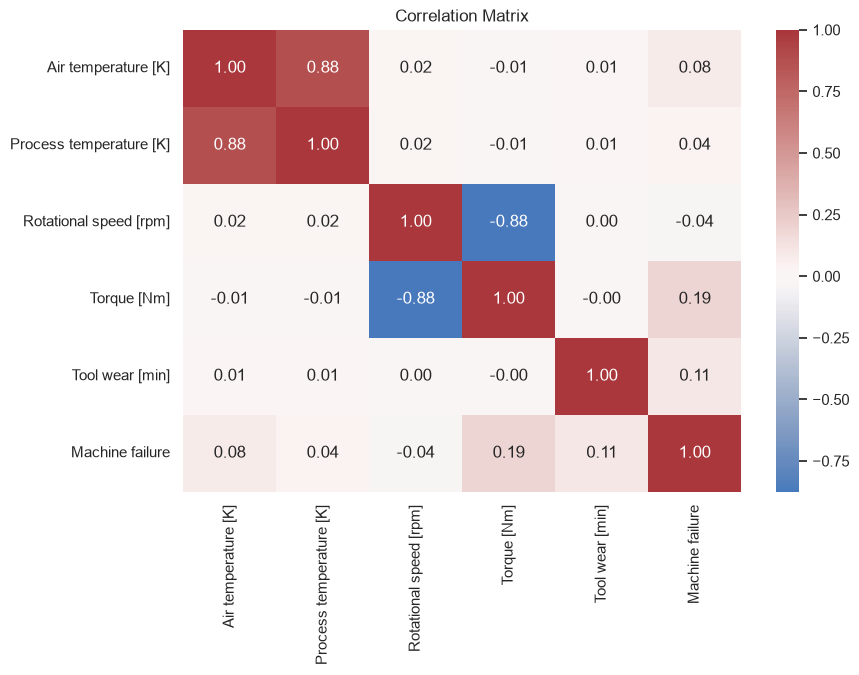

In [10]:
correlation_columns = BASE_NUMERIC_FEATURES + [TARGET_COLUMN]
correlations = clean_df[correlation_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlations, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

,count,failure_rate
Type,,
H,1003,0.020937
L,6000,0.039167
M,2997,0.027694


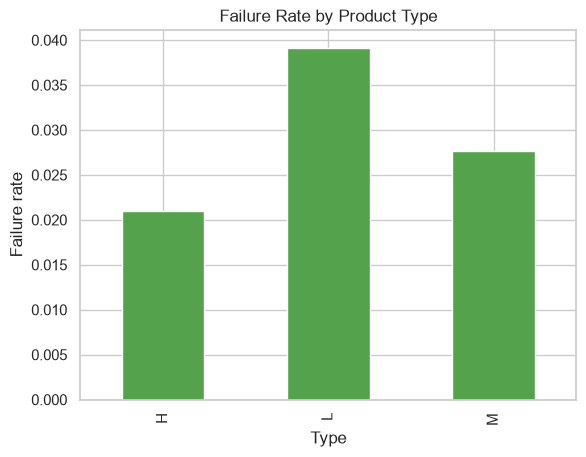

In [11]:
type_failure_rate = clean_df.groupby("Type", observed=True)[TARGET_COLUMN].agg(["count", "mean"])
display(type_failure_rate.rename(columns={"mean": "failure_rate"}))

ax = type_failure_rate["mean"].plot(kind="bar", color="#54A24B")
ax.set_title("Failure Rate by Product Type")
ax.set_xlabel("Type")
ax.set_ylabel("Failure rate")
plt.show()

# 10. Feature Selection

The model should use operating and product characteristics that can plausibly be observed before failure. The initial candidate features are product type, temperatures, rotational speed, torque, and tool wear.

In [12]:
candidate_feature_columns = get_model_feature_columns(clean_df)
candidate_feature_columns

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]']

# 11. Leakage Prevention

The columns `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` represent specific failure modes. They are closely associated with failure information and would not represent appropriate independent pre-failure input variables for this intended prediction setup.

The identifier columns `UDI` and `Product ID` are also excluded because they do not represent useful operating information for a generalizable model.

In [13]:
excluded_columns = IDENTIFIER_COLUMNS + FAILURE_MODE_COLUMNS
pd.DataFrame({"excluded_column": excluded_columns})

,excluded_column
0,UDI
1,Product ID
2,TWF
3,HDF
4,PWF
5,OSF
6,RNF


# 12. Feature Engineering

Two simple engineered features are added:

- `Temperature Difference [K]`: process temperature minus air temperature.
- `Torque Speed Product`: a simple load-related interaction between torque and rotational speed.

Both features have direct interpretations and the original variables are retained.

In [14]:
model_df = add_engineered_features(clean_df)
display(model_df[["Temperature Difference [K]", "Torque Speed Product"]].describe())

,Temperature Difference [K],Torque Speed Product
count,10000.000000,10000.000000
mean,10.000630,59967.147040
std,1.001094,10193.093881
min,7.600000,10966.800000
25%,9.300000,53105.400000
50%,9.800000,59883.900000
75%,11.000000,66873.750000
max,12.100000,99980.400000


# 13. Train / Validation / Test Split

A stratified 70/15/15 split is used so each split preserves the failure-rate pattern as much as possible.

In [15]:
X_train, X_validation, X_test, y_train, y_validation, y_test = split_train_validation_test(model_df)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_validation), len(X_test)],
        "failure_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
display(split_summary)

,rows,failure_rate
train,7000,0.033857
validation,1500,0.034000
test,1500,0.034000


# 14. Preprocessing Pipeline

Numerical features are scaled and categorical features are one-hot encoded inside scikit-learn pipelines. This keeps preprocessing fitted only on training data.

In [16]:
preprocessor = build_preprocessor(X_train)
models = build_models(preprocessor)
models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest'])

# 15. Logistic Regression Baseline

Before using a more complex model, we need a simple baseline. Logistic Regression is useful because it is relatively interpretable and sets a clear performance reference.

In [17]:
logistic_model = models["Logistic Regression"]
logistic_model.fit(X_train, y_train)
evaluate_model(logistic_model, X_validation, y_validation)

{'Accuracy': 0.8473333333333334,
 'Precision': 0.15234375,
 'Recall': 0.7647058823529411,
 'F1': 0.254071661237785,
 'ROC-AUC': 0.87738670347366}

# 16. Decision Tree

A Decision Tree can capture simple nonlinear relationships while still being easier to explain than many advanced models.

In [18]:
decision_tree_model = models["Decision Tree"]
decision_tree_model.fit(X_train, y_train)
evaluate_model(decision_tree_model, X_validation, y_validation)

{'Accuracy': 0.938,
 'Precision': 0.325,
 'Recall': 0.7647058823529411,
 'F1': 0.45614035087719296,
 'ROC-AUC': 0.8915546895086537}

# 17. Random Forest

A Random Forest is used as the main nonlinear ensemble comparison. It remains simple enough for this project while often improving stability over a single tree.

In [19]:
random_forest_model = models["Random Forest"]
random_forest_model.fit(X_train, y_train)
evaluate_model(random_forest_model, X_validation, y_validation)

{'Accuracy': 0.9873333333333333,
 'Precision': 0.8809523809523809,
 'Recall': 0.7254901960784313,
 'F1': 0.7956989247311828,
 'ROC-AUC': 0.9482739955885736}

# 18. Model Evaluation

The models are compared side by side using accuracy, precision, recall, F1-score, and ROC-AUC. The final choice should consider the trade-off between detecting failures and avoiding unnecessary alerts.

In [20]:
preprocessor = build_preprocessor(X_train)
models = build_models(preprocessor)
validation_metrics = fit_and_evaluate_models(models, X_train, y_train, X_validation, y_validation)
display(validation_metrics.sort_values(["Recall", "F1"], ascending=False))

selected_model_name = validation_metrics.sort_values(["Recall", "F1"], ascending=False).iloc[0]["Model"]
final_model = models[selected_model_name]
print(f"Selected final model based on validation recall and F1 trade-off: {selected_model_name}")

test_metrics = evaluate_model(final_model, X_test, y_test)
display(pd.DataFrame([test_metrics], index=[selected_model_name]))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Decision Tree,0.938000,0.325000,0.764706,0.456140,0.891555
0,Logistic Regression,0.847333,0.152344,0.764706,0.254072,0.877387
2,Random Forest,0.987333,0.880952,0.725490,0.795699,0.948274


Selected final model based on validation recall and F1 trade-off: Decision Tree


,Accuracy,Precision,Recall,F1,ROC-AUC
Decision Tree,0.928667,0.313333,0.921569,0.467662,0.936555


# 19. Confusion Matrix Analysis

- True Positive: the model flags a machine and it actually fails.
- False Positive: the model flags a machine but it does not fail.
- False Negative: the model says normal but the machine actually fails.
- True Negative: the model says normal and the machine does not fail.

False negatives deserve particular attention because missed failures may lead to unplanned downtime or safety issues.

In [21]:
confusion_matrix_dataframe(final_model, X_test, y_test)

,Predicted: No Failure,Predicted: Failure
Actual: No Failure,1346,103
Actual: Failure,4,47


# 20. Threshold Analysis

The predicted probability and the final maintenance decision are not exactly the same thing. Changing the threshold changes precision, recall, and F1.

,Threshold,Precision,Recall,F1
0,0.2,0.325,0.764706,0.45614
1,0.3,0.325,0.764706,0.45614
2,0.4,0.325,0.764706,0.45614
3,0.5,0.325,0.764706,0.45614
4,0.6,0.325,0.764706,0.45614


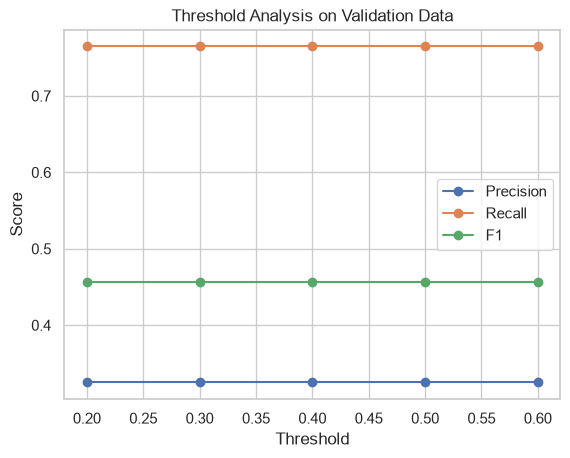

In [22]:
threshold_results = threshold_analysis(final_model, X_validation, y_validation)
display(threshold_results)

ax = threshold_results.plot(x="Threshold", y=["Precision", "Recall", "F1"], marker="o")
ax.set_title("Threshold Analysis on Validation Data")
ax.set_ylabel("Score")
plt.show()

# 21. Feature Importance / Interpretation

Feature importance shows model association, not causation. A high importance value means the model used that feature heavily for prediction; it does not prove the feature causes failure.

,Feature,Importance,Absolute Value
0,numeric__Rotational speed [rpm],0.347096,0.347096
1,numeric__Tool wear [min],0.251591,0.251591
2,numeric__Torque Speed Product,0.230681,0.230681
3,numeric__Torque [Nm],0.113962,0.113962
4,numeric__Temperature Difference [K],0.050738,0.050738
5,numeric__Air temperature [K],0.003583,0.003583
6,numeric__Process temperature [K],0.002348,0.002348
7,categorical__Type_H,0.000000,0.000000
8,categorical__Type_L,0.000000,0.000000
9,categorical__Type_M,0.000000,0.000000


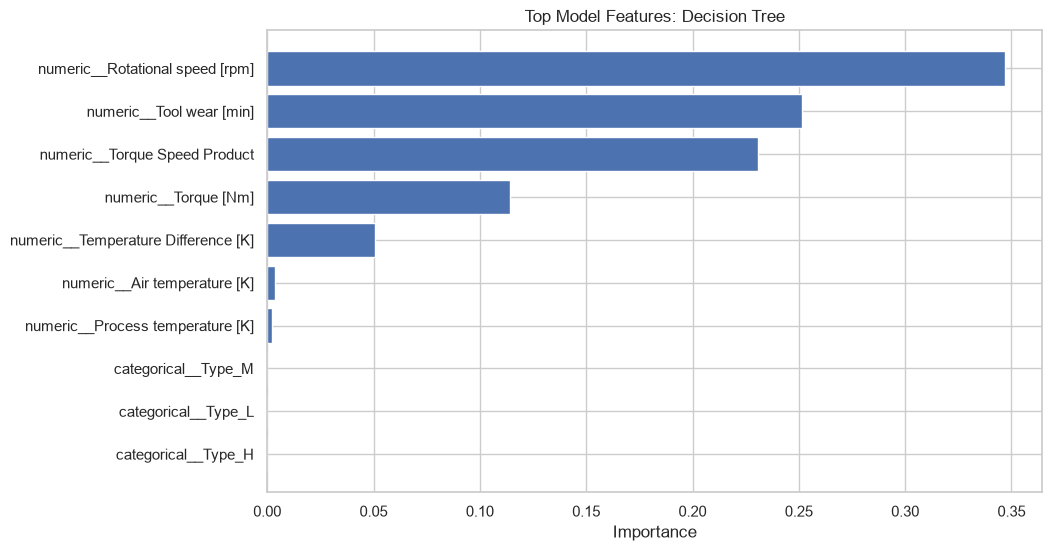

In [23]:
importance = feature_importance_dataframe(final_model)
display(importance.head(10))

plot_column = "Importance" if "Importance" in importance.columns else "Coefficient"
top_importance = importance.head(10).sort_values("Absolute Value")

plt.figure(figsize=(10, 6))
plt.barh(top_importance["Feature"], top_importance[plot_column])
plt.title(f"Top Model Features: {selected_model_name}")
plt.xlabel(plot_column)
plt.show()

# 22. Individual Machine Prediction

The reusable prediction function accepts one machine's operating characteristics and returns failure probability, predicted class, risk interpretation, notable characteristics, and a maintenance-oriented next step.

In [24]:
example_machine = X_test.iloc[0].to_dict()
prediction_result = predict_machine_failure(
    final_model,
    example_machine,
    threshold=0.5,
    reference_data=X_train,
)
prediction_result

{'failure_probability': 0.05039127187108095,
 'predicted_class': 0,
 'risk_interpretation': 'Low Failure Risk',
 'notable_characteristics': ['Temperature Difference [K] is below the training-data lower quartile'],
 'recommended_next_step': 'Predicted failure risk is low. Continue routine monitoring.'}

# 23. Business Interpretation

The model predicts risk; it does not diagnose the exact mechanical fault.

Prediction does not equal diagnosis. A high predicted risk should be interpreted as a signal for further inspection according to the relevant maintenance procedure.

In [25]:
print(f"Failure probability: {prediction_result['failure_probability']:.3f}")
print(f"Prediction class: {prediction_result['predicted_class']}")
print(f"Risk interpretation: {prediction_result['risk_interpretation']}")
print("Notable characteristics:")
for item in prediction_result["notable_characteristics"]:
    print(f"- {item}")
print(f"Recommended next step: {prediction_result['recommended_next_step']}")

Failure probability: 0.050
Prediction class: 0
Risk interpretation: Low Failure Risk
Notable characteristics:
- Temperature Difference [K] is below the training-data lower quartile
Recommended next step: Predicted failure risk is low. Continue routine monitoring.


# 24. Limitations

- The dataset is synthetic.
- Model performance on this dataset does not guarantee real-world factory performance.
- Correlation and model importance do not establish causality.
- Predictive maintenance deployment requires appropriate real-world sensor and maintenance data.

# 25. Conclusion

This project demonstrates a complete, interview-ready predictive maintenance workflow: data understanding, cleaning, focused EDA, leakage-aware feature selection, simple feature engineering, stratified splitting, preprocessing, baseline modelling, model comparison, threshold analysis, explainability, and individual risk prediction.